<a href="https://colab.research.google.com/github/MonishDY/AI-Track/blob/main/Module%203%20-%20Machine%20Learning/Assignment%204/Monish_DY_Assignment_4_ML_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

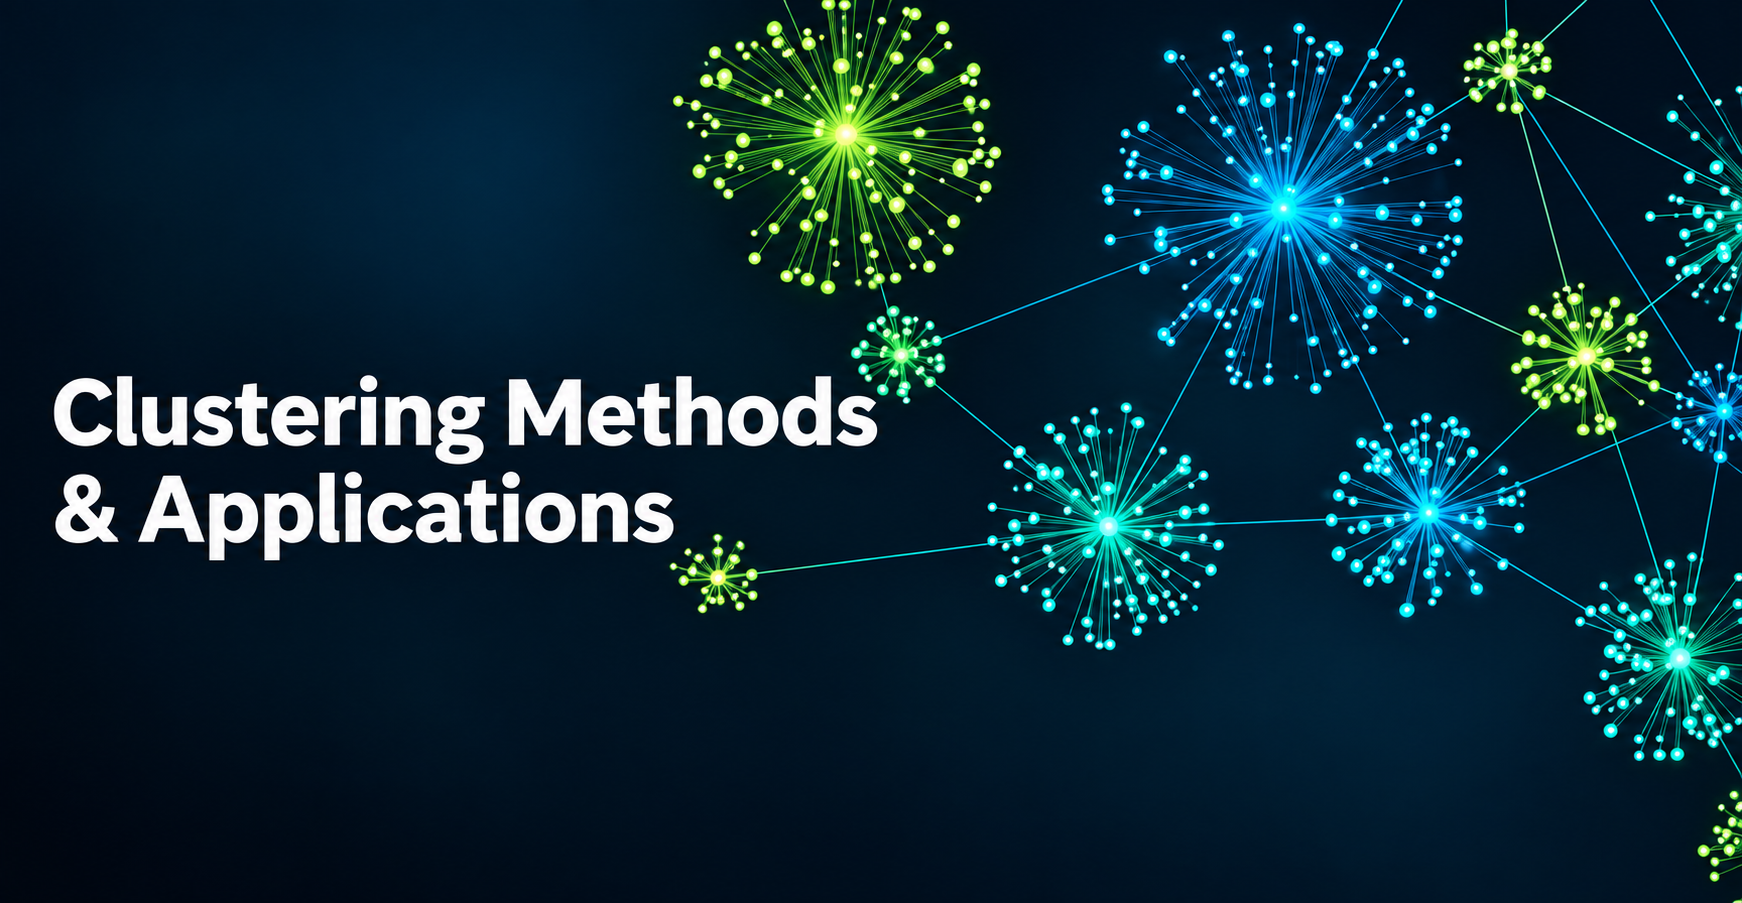

# **UNSUPERVISED LEARNING - CLUSTERING TECHNIQUES AND CLUSTER EVALUATION**

## **Overall Objectives**

1. Understand the working of **K-Means clustering** and centroid-based grouping.
2. Determine the optimal number of clusters using the **Elbow Method**.
3. Apply **Hierarchical Clustering** and visualize cluster formation using a dendrogram.
4. Identify clusters and noise points using the **DBSCAN** algorithm.
5. Evaluate clustering quality using **Silhouette Score** and **Davies-Bouldin Index**.

## **1. K-Means Clustering**

### **Objective**

To group the given data points into 3 clusters using K-Means and display their labels and centroids.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# Define the data points
df = pd.DataFrame([
    (1, 2), (2, 3), (3, 1),
    (8, 9), (9, 8), (10, 10),
    (15, 16), (16, 15)
], columns=['X', 'Y'])

points = df[['X', 'Y']].values
df

,X,Y
0,1,2
1,2,3
2,3,1
3,8,9
4,9,8
5,10,10
6,15,16
7,16,15


In [3]:
# Perform KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(points)

In [4]:
# Display the cluster labels for each point
print("Cluster Labels:")
df['Cluster'] = labels
df

Cluster Labels:


,X,Y,Cluster
0,1,2,0
1,2,3,0
2,3,1,0
3,8,9,2
4,9,8,2
5,10,10,2
6,15,16,1
7,16,15,1


In [5]:
# Display the centroids of the clusters
centroids_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['X', 'Y']
)

centroids_df.index.name = 'Cluster'

centroids_df

,X,Y
Cluster,,
0,2.0,2.0
1,15.5,15.5
2,9.0,9.0


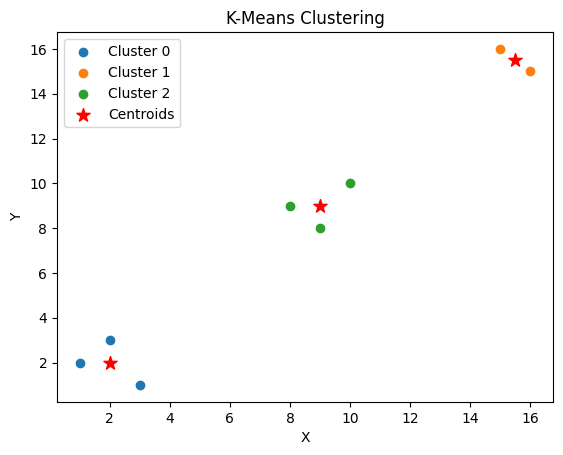

In [6]:
# Visualize the clusters
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(
        cluster_data['X'],
        cluster_data['Y'],
        label=f'Cluster {cluster}'
    )

# Plot centroids
plt.scatter(
    centroids_df['X'],
    centroids_df['Y'],
    marker='*',
    color='red',
    s=100,
    label='Centroids'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

### **Result**

- The given 8 data points were grouped into 3 clusters.
- The corresponding centroids were calculated for each cluster.
- The points around (1–3, 1–3), (8–10, 8–10), and (15–16, 15–16) formed the three groups.

## **2. Elbow Method**

### **Objective**

To determine the optimal number of clusters for the Iris dataset using the Elbow Method.

In [7]:
# Import necessary libraries for Iris dataset
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [8]:
# Load Iris dataset
iris = load_iris()
X = iris.data

In [9]:
# Perform KMeans clustering on the Iris dataset
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

In [10]:
# Print the inertia values
inertia_df = pd.DataFrame({
    'K': range(2, 11),
    'Inertia': inertia
}).reset_index(drop=True)

inertia_df

,K,Inertia
0,2,152.347952
1,3,78.851441
2,4,57.228473
3,5,46.461173
4,6,39.039987
5,7,34.305815
6,8,30.132441
7,9,28.290635
8,10,25.970930


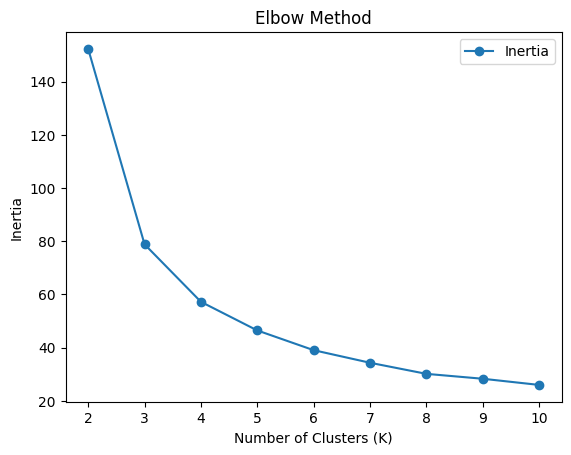

In [11]:
# Visualize the inertia values
plt.plot(
    inertia_df['K'],
    inertia_df['Inertia'],
    marker='o',
    label='Inertia'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(2, 11))
plt.legend()
plt.show()

### **Result**

- K-Means was tested for different values of K from 2 to 10 on the Iris dataset.
- The Inertia decreased as the number of clusters increased.
- The Elbow Method indicated **K = 3** as a suitable number of clusters.

## **3. Hierarchical Clustering**

### **Objective**

To apply Agglomerative Clustering on the Iris dataset and visualize the hierarchical structure using a dendrogram.

In [12]:
# Import the necessary libraries for Agglomerative Clustering
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [13]:
# Load Iris dataset
iris = load_iris()
X = iris.data

In [14]:
# Perform Agglomerative Clustering on the Iris dataset
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X)

In [15]:
# Create DataFrame with Iris features and cluster labels
hierarchical_df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

hierarchical_df['Cluster'] = hierarchical_labels
hierarchical_df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1


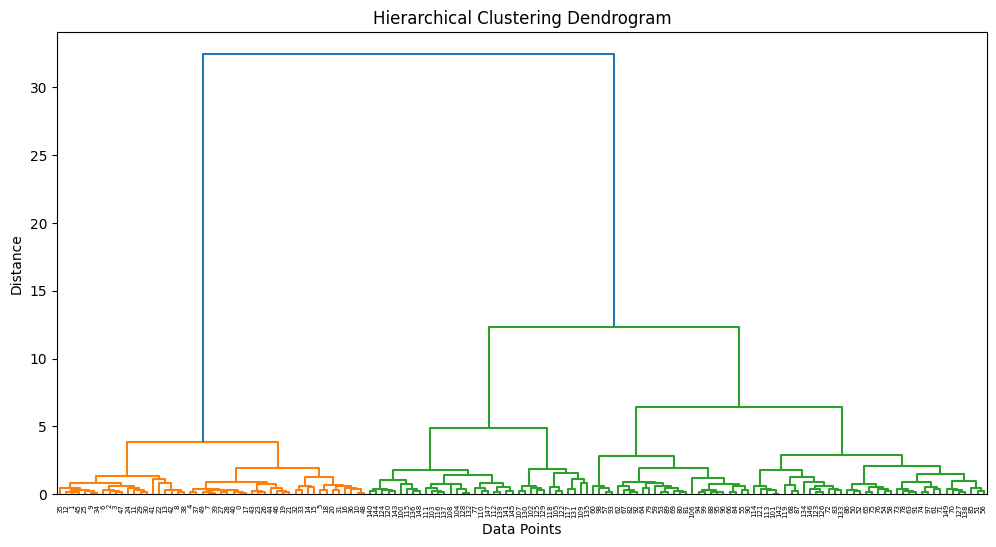

In [16]:
# Visualize the dendrogram
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

### **Result**

- Agglomerative Hierarchical Clustering was applied to the Iris dataset.
- The data was divided into **3 clusters.**
- A dendrogram was generated to visualize how individual data points progressively merge into larger clusters.
- The result shows that the Iris samples have distinguishable hierarchical groupings.

## **4. DBSCAN**

### **Objective**

To apply DBSCAN on a dataset containing outliers and identify the noise points.

In [17]:
# Import necessary libraries for DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [18]:
# Define the data points for DBSCAN
dbscan_df = pd.DataFrame([
    [1, 1], [1.2, 1.1], [0.8, 1.2],
    [2, 1.5], [2.2, 1.3], [1.8, 1.7],
    [8, 8], [8.2, 8.1], [7.8, 8.3],
    [9, 8.5], [8.7, 8.2],
    [15, 15], [20, 20]
], columns=['X', 'Y'])

points = dbscan_df[['X', 'Y']].values
dbscan_df

,X,Y
0,1.0,1.0
1,1.2,1.1
2,0.8,1.2
3,2.0,1.5
4,2.2,1.3
5,1.8,1.7
6,8.0,8.0
7,8.2,8.1
8,7.8,8.3
9,9.0,8.5


In [19]:
# Perform DBSCAN clustering
dbscan = DBSCAN(eps=0.8, min_samples=3)
labels = dbscan.fit_predict(points)

In [20]:
# Display the cluster labels for each point
dbscan_df['Cluster'] = labels
dbscan_df['Cluster'] = dbscan_df['Cluster'].apply(
    lambda x: 'Noise' if x == -1 else f'Cluster {x}'
)

dbscan_df

,X,Y,Cluster
0,1.0,1.0,Cluster 0
1,1.2,1.1,Cluster 0
2,0.8,1.2,Cluster 0
3,2.0,1.5,Cluster 1
4,2.2,1.3,Cluster 1
5,1.8,1.7,Cluster 1
6,8.0,8.0,Cluster 2
7,8.2,8.1,Cluster 2
8,7.8,8.3,Cluster 2
9,9.0,8.5,Cluster 2


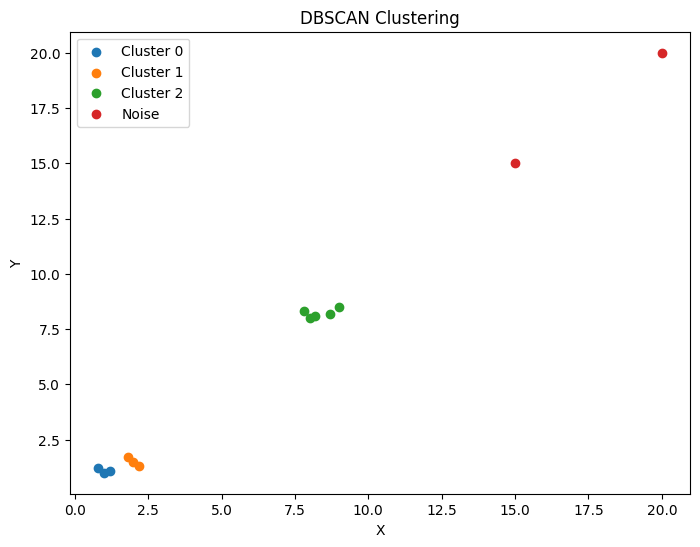

In [21]:
# Visualize the DBSCAN clusters
plt.figure(figsize=(8, 6))

for cluster in dbscan_df['Cluster'].unique():
    cluster_data = dbscan_df[dbscan_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['X'],
        cluster_data['Y'],
        label=cluster
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

### **Result**

- DBSCAN identified 3 dense clusters in the given dataset.
- The isolated points (15,15) and (20,20) were identified as noise/outliers with DBSCAN label -1.

## **5. Cluster Evaluation**

### **Objective**

To evaluate the quality of K-Means clusters on the Iris dataset using Silhouette Score and Davies-Bouldin Index.

In [22]:
# Import necessary libraries for KMeans evaluation
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [23]:
# Load Iris dataset
iris = load_iris()
X = iris.data

In [24]:
# Perform Elbow method for KMeans clustering on the Iris dataset
results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_labels = kmeans.fit_predict(X)

    results.append([
        k,
        kmeans.inertia_,
        silhouette_score(X, k_labels),
        davies_bouldin_score(X, k_labels)
    ])

In [25]:
# Create a DataFrame to display the results
results_df = pd.DataFrame(
    results,
    columns=['K', 'Inertia', 'Silhouette Score', 'Davies-Bouldin Index']
)

results_df

,K,Inertia,Silhouette Score,Davies-Bouldin Index
0,2,152.347952,0.681046,0.404293
1,3,78.851441,0.552819,0.661972
2,4,57.228473,0.498051,0.780307
3,5,46.461173,0.491240,0.815989
4,6,39.039987,0.364834,0.914158
5,7,34.305815,0.354298,0.978573
6,8,30.132441,0.348735,0.951887
7,9,28.290635,0.312504,1.032386
8,10,25.970930,0.317966,1.017150


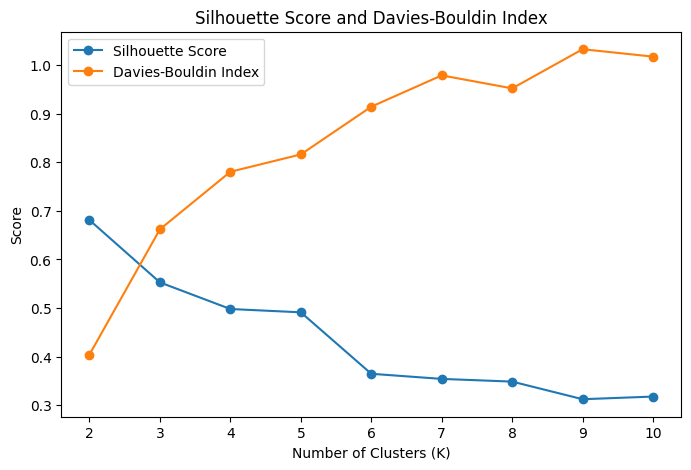

In [26]:
# Visualize the Silhouette Score and Davies-Bouldin Index
plt.figure(figsize=(8, 5))

plt.plot(
    results_df['K'],
    results_df['Silhouette Score'],
    marker='o',
    label='Silhouette Score'
)

plt.plot(
    results_df['K'],
    results_df['Davies-Bouldin Index'],
    marker='o',
    label='Davies-Bouldin Index'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.title("Silhouette Score and Davies-Bouldin Index")
plt.xticks(range(2, 11))
plt.legend()
plt.show()

### **Result**
- **Silhouette Score:** measures how well each point fits within its assigned cluster; higher values indicate better clustering.
- **Davies-Bouldin Index:** measures similarity between clusters; lower values indicate better clustering.
- The evaluation supported **K = 3** as a suitable clustering choice for the Iris dataset.

## **Conclusion**

- **K-Means Clustering:** Grouped the given data points into 3 clusters and identified their corresponding centroids.

- **Elbow Method:** Determined the optimal number of clusters for the Iris dataset by analyzing the variation in inertia.

- **Hierarchical Clustering:** Applied Agglomerative Clustering and visualized the hierarchical relationships between data points using a dendrogram.

- **DBSCAN:** Identified dense clusters and detected outliers as noise points using density-based clustering.

- **Cluster Evaluation:** Evaluated K-Means clustering performance using Silhouette Score and Davies-Bouldin Index.

Overall, different clustering techniques help identify meaningful patterns and groups in unlabeled data, while cluster evaluation metrics provide a quantitative measure of clustering quality.

---
### **Completed By:** *Monish D.Y. - 230701195*